# Q1: What is Anomaly Detection? Explain its types (point, contextual, collective anomalies) with examples.
Anomaly Detection is the process of identifying data points that deviate from normal patterns.

Types:
1. Point Anomaly:
   A single data point is abnormal.
   Example: Sudden spike in credit card transaction.

2. Contextual Anomaly:
   Abnormal depending on context.
   Example: High temperature in winter.

3. Collective Anomaly:
   A group of data points is abnormal.
   Example: Continuous unusual network traffic.

# Q2: Compare Isolation Forest, DBSCAN, and Local Outlier Factor in terms of their approach and suitable use cases.

"""
Isolation Forest:
- Approach: Tree-based isolation
- Use Case: High-dimensional data
- Advantage: Fast and scalable

DBSCAN:
- Approach: Density-based clustering
- Use Case: Spatial data
- Advantage: Detects noise

LOF:
- Approach: Local density comparison
- Use Case: Local anomaly detection
- Advantage: Detects subtle anomalies
"""

# Q3: What are the key components of a Time Series? Explain each with one example.

"""
1. Trend:
   Long-term increase/decrease
   Example: Sales growth over years

2. Seasonality:
   Repeating patterns
   Example: Festival sales

3. Cyclical:
   Long-term fluctuations
   Example: Economic cycles

4. Residual:
   Random noise
   Example: Unexpected events
"""

# Q4: Define Stationarity in time series. How can you test and transform a non-stationary series into a stationary one?

"""
Stationarity means mean, variance, and covariance are constant over time.

Testing:
- Augmented Dickey-Fuller (ADF) test

Transformation:
- Differencing
- Log transformation
- Removing trend/seasonality
"""

# Q5: Differentiate between AR, MA, ARIMA, SARIMA, and SARIMAX models in terms of structure and application.

"""
AR: Uses past values
MA: Uses past errors
ARIMA: AR + MA + Differencing
SARIMA: ARIMA + seasonality
SARIMAX: SARIMA + external variables
"""

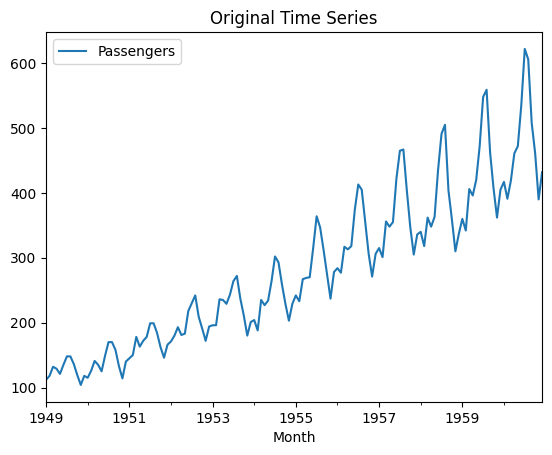

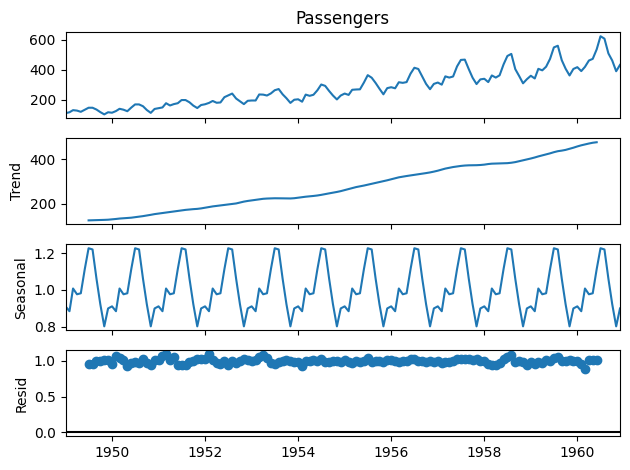

In [2]:
# Q6: Load a time series dataset (AirPassengers), plot the original series,
# and decompose it into trend, seasonality, and residual components.

import pandas as pd
import matplotlib.pyplot as plt
from statsmodels.tsa.seasonal import seasonal_decompose

data = pd.read_csv('https://raw.githubusercontent.com/jbrownlee/Datasets/master/airline-passengers.csv')
data['Month'] = pd.to_datetime(data['Month'])
data.set_index('Month', inplace=True)

data.plot(title="Original Time Series")
plt.show()

decomp = seasonal_decompose(data['Passengers'], model='multiplicative')
decomp.plot()
plt.show()

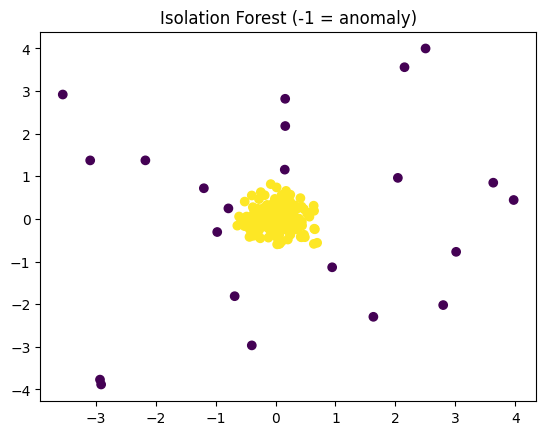

In [3]:
# Q7: Apply Isolation Forest on a numerical dataset to detect anomalies.
# Visualize anomalies on a 2D scatter plot.

import numpy as np
import matplotlib.pyplot as plt
from sklearn.ensemble import IsolationForest

rng = np.random.RandomState(42)
X = 0.3 * rng.randn(200, 2)
X_outliers = rng.uniform(low=-4, high=4, size=(20, 2))
X = np.r_[X, X_outliers]

model = IsolationForest(contamination=0.1)
labels = model.fit_predict(X)

plt.scatter(X[:, 0], X[:, 1], c=labels)
plt.title("Isolation Forest (-1 = anomaly)")
plt.show()

C:\Users\hp\AppData\Local\Programs\Python\Python313\Lib\site-packages\statsmodels\tsa\base\tsa_model.py:473: ValueWarning: No frequency information was provided, so inferred frequency MS will be used.
  self._init_dates(dates, freq)
C:\Users\hp\AppData\Local\Programs\Python\Python313\Lib\site-packages\statsmodels\tsa\base\tsa_model.py:473: ValueWarning: No frequency information was provided, so inferred frequency MS will be used.
  self._init_dates(dates, freq)


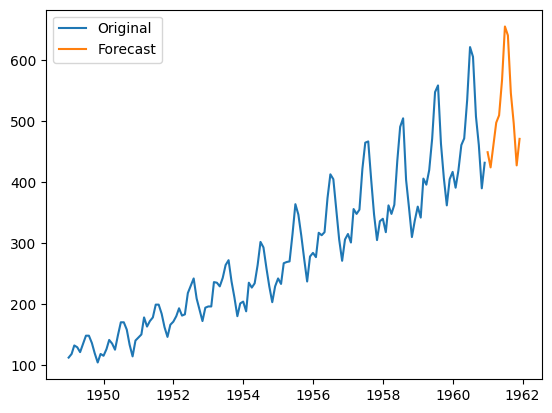

In [4]:
# Q8: Train a SARIMA model on the AirPassengers dataset.
# Forecast the next 12 months and visualize results.

import pandas as pd
import matplotlib.pyplot as plt
from statsmodels.tsa.statespace.sarimax import SARIMAX

data = pd.read_csv('https://raw.githubusercontent.com/jbrownlee/Datasets/master/airline-passengers.csv')
data['Month'] = pd.to_datetime(data['Month'])
data.set_index('Month', inplace=True)

model = SARIMAX(data['Passengers'], order=(1,1,1), seasonal_order=(1,1,1,12))
results = model.fit()

forecast = results.forecast(steps=12)

plt.plot(data, label='Original')
plt.plot(forecast, label='Forecast')
plt.legend()
plt.show()

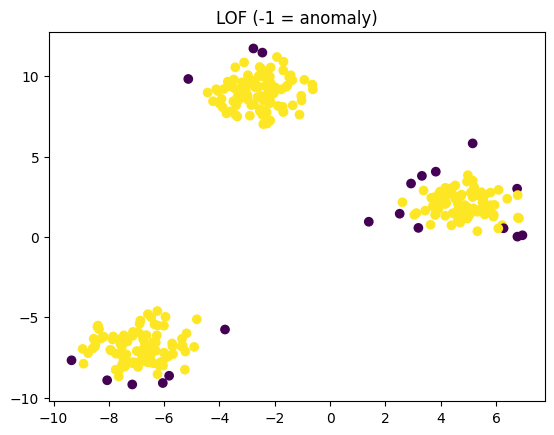

In [5]:
# Q9: Apply Local Outlier Factor (LOF) on a numerical dataset to detect anomalies
# and visualize them using matplotlib.

import matplotlib.pyplot as plt
from sklearn.neighbors import LocalOutlierFactor
from sklearn.datasets import make_blobs

X, _ = make_blobs(n_samples=300, centers=3, random_state=42)

lof = LocalOutlierFactor(n_neighbors=20)
labels = lof.fit_predict(X)

plt.scatter(X[:, 0], X[:, 1], c=labels)
plt.title("LOF (-1 = anomaly)")
plt.show()

# Q10: Real-time data science workflow for power grid monitoring

"""
1. Anomaly Detection:
   Use Isolation Forest for fast streaming detection.
   LOF for local anomalies.
   DBSCAN for density anomalies.

2. Forecasting:
   Use SARIMAX (handles seasonality + weather features).

3. Validation:
   - Rolling window validation
   - Metrics: MAE, RMSE
   - Monitor drift

4. Business Impact:
   - Detect power spikes early
   - Prevent outages
   - Optimize energy distribution
"""